In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ethiopia = pd.read_csv("../data/ethiopia.csv")
kenya = pd.read_csv("../data/kenya.csv")
sudan = pd.read_csv("../data/sudan.csv")
tanzania = pd.read_csv("../data/tanzania.csv")
nigeria = pd.read_csv("../data/nigeria.csv")

In [4]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [5]:
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [6]:
df["Country"].unique()

<StringArray>
['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
Length: 5, dtype: str

In [7]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [8]:
df["Country"].value_counts()


Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

In [9]:
df["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

In [11]:
print(ethiopia.head())
print(kenya.head())
print(sudan.head())
print(tanzania.head())
print(nigeria.head())

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M   Country  
0      5.07  77.13  4.00  Ethiopia  
1      4.19  77.14  3.35  Ethiopia  
2      2.76  77.11  3.43  Ethiopia  
3      1.28  77.07  4.60  Ethiopia  
4      2.14  77.01  5.58  Ethiopia  
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  19.56    28.99    12.09      16.90         0.00  45.32  3.12   
1  2015    2  19.63    29.77    11.04      18.73         0.00  38.76  3.23   
2  2015    3  20.40    30.57    11.71      18.86         0.00  41.75  3.46 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ethiopia = pd.read_csv("../data/ethiopia.csv")
kenya = pd.read_csv("../data/kenya.csv")
sudan = pd.read_csv("../data/sudan.csv")
tanzania = pd.read_csv("../data/tanzania.csv")
nigeria = pd.read_csv("../data/nigeria.csv")

ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

df.replace(-999, np.nan, inplace=True)
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month

df["Country"].value_counts()

Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

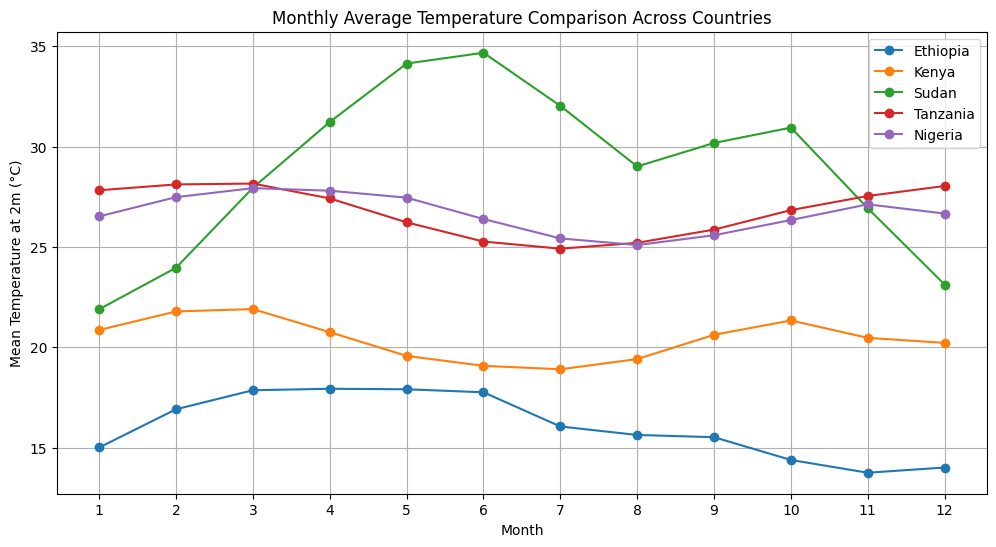

In [13]:
plt.figure(figsize=(12,6))

for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    monthly_avg = subset.groupby("MONTH")["T2M"].mean()
    plt.plot(monthly_avg.index, monthly_avg.values, marker="o", label=country)

plt.title("Monthly Average Temperature Comparison Across Countries")
plt.xlabel("Month")
plt.ylabel("Mean Temperature at 2m (°C)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

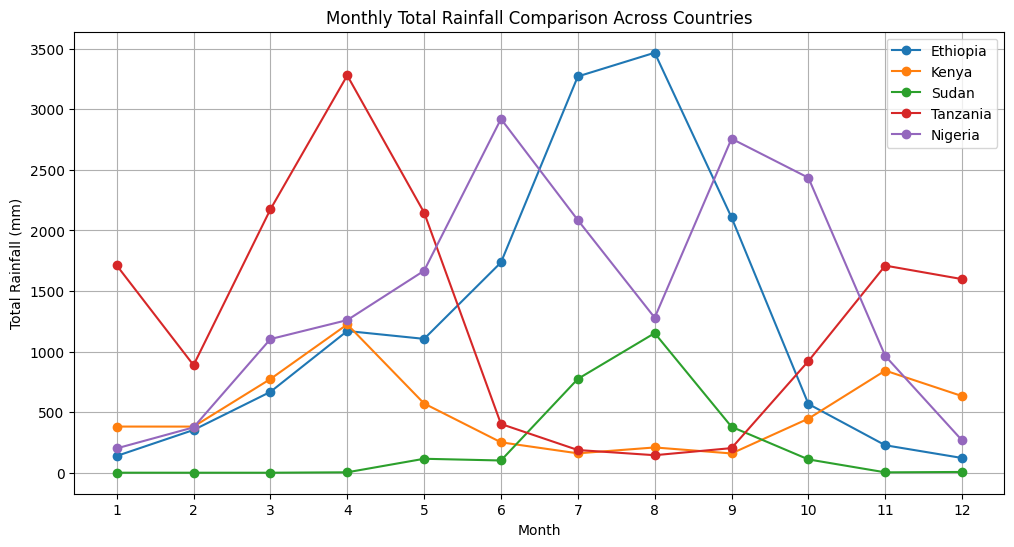

In [14]:
plt.figure(figsize=(12,6))

for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    monthly_rain = subset.groupby("MONTH")["PRECTOTCORR"].sum()
    plt.plot(monthly_rain.index, monthly_rain.values, marker="o", label=country)

plt.title("Monthly Total Rainfall Comparison Across Countries")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()

## Cross-Country Rainfall Comparison

The rainfall patterns vary significantly across the countries.

Some countries exhibit strong seasonal rainfall peaks, while others show more moderate or irregular patterns.  
Countries with concentrated rainfall periods may be more vulnerable to flooding, while those with low or inconsistent rainfall may face drought risks.

These variations highlight the diverse climatic conditions across the region and their implications for agriculture and water resource management.

In [15]:
heat_extremes = df[df["T2M_MAX"] > 35]

heat_counts = heat_extremes["Country"].value_counts()
heat_counts

Country
Sudan    2694
Name: count, dtype: int64

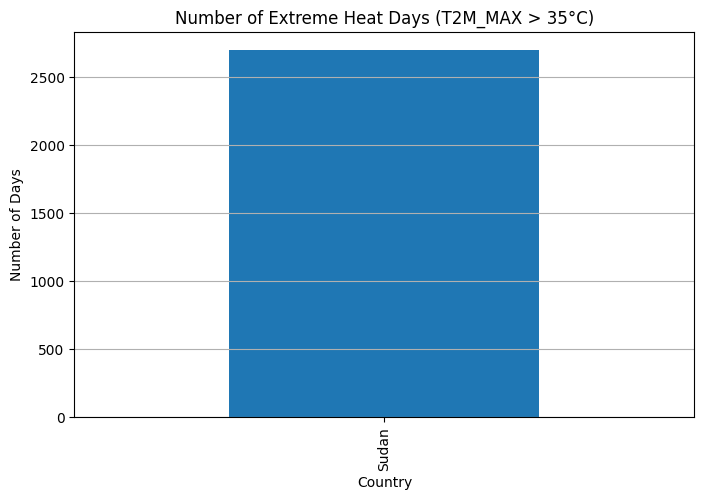

In [16]:
heat_counts.plot(kind="bar", figsize=(8,5))

plt.title("Number of Extreme Heat Days (T2M_MAX > 35°C)")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(axis='y')

plt.show()

## Extreme Heat Analysis

Extreme heat events were defined as days where the maximum temperature exceeded 35°C.

The analysis shows significant variation across countries, with some experiencing a much higher number of extreme heat days.

Countries with frequent extreme heat events may face increased risks related to public health, agriculture, and water availability.

In [17]:
# 1) Extreme heat counts (you already computed)
heat_counts = df[df["T2M_MAX"] > 35]["Country"].value_counts()

# 2) Total rainfall per country
total_rain = df.groupby("Country")["PRECTOTCORR"].sum()

# 3) Rainfall variability (standard deviation)
rain_var = df.groupby("Country")["PRECTOTCORR"].std()

# Combine into one table
score_df = pd.DataFrame({
    "Extreme_Heat": heat_counts,
    "Total_Rainfall": total_rain,
    "Rainfall_Variability": rain_var
}).fillna(0)

score_df

,Extreme_Heat,Total_Rainfall,Rainfall_Variability
Country,,,
Ethiopia,0.0,14927.63,6.289061
Kenya,0.0,6031.21,3.180228
Nigeria,0.0,17310.76,7.266742
Sudan,2694.0,2645.04,3.057672
Tanzania,0.0,15364.97,8.003947


In [18]:
# Normalize 0–1
norm_df = (score_df - score_df.min()) / (score_df.max() - score_df.min())
norm_df

,Extreme_Heat,Total_Rainfall,Rainfall_Variability
Country,,,
Ethiopia,0.0,0.837503,0.653297
Kenya,0.0,0.230890,0.024777
Nigeria,0.0,1.000000,0.850958
Sudan,1.0,0.000000,0.000000
Tanzania,0.0,0.867324,1.000000


In [19]:
norm_df["Low_Rainfall_Risk"] = 1 - norm_df["Total_Rainfall"]

norm_df["Vulnerability_Score"] = (
    0.4 * norm_df["Extreme_Heat"] +
    0.3 * norm_df["Rainfall_Variability"] +
    0.3 * norm_df["Low_Rainfall_Risk"]
)

norm_df.sort_values("Vulnerability_Score", ascending=False)

,Extreme_Heat,Total_Rainfall,Rainfall_Variability,Low_Rainfall_Risk,Vulnerability_Score
Country,,,,,
Sudan,1.0,0.000000,0.000000,1.000000,0.700000
Tanzania,0.0,0.867324,1.000000,0.132676,0.339803
Nigeria,0.0,1.000000,0.850958,0.000000,0.255287
Ethiopia,0.0,0.837503,0.653297,0.162497,0.244738
Kenya,0.0,0.230890,0.024777,0.769110,0.238166


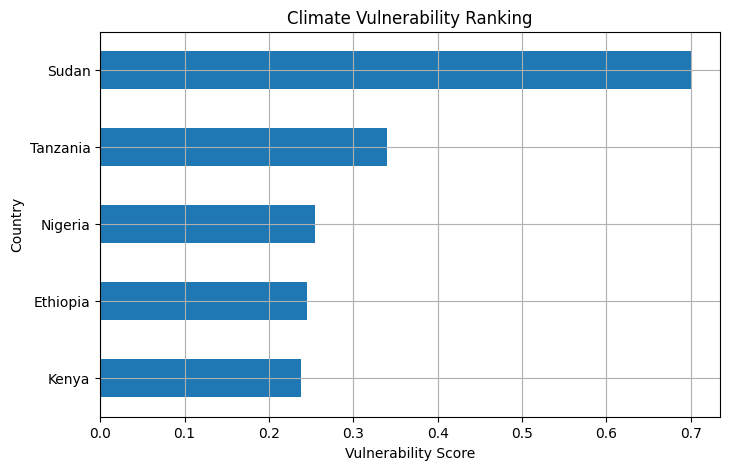

In [20]:
norm_df.sort_values("Vulnerability_Score")["Vulnerability_Score"].plot(
    kind="barh", figsize=(8,5)
)

plt.title("Climate Vulnerability Ranking")
plt.xlabel("Vulnerability Score")
plt.ylabel("Country")
plt.grid(True)

plt.show()

## Climate Vulnerability Ranking

A composite vulnerability score was developed based on three indicators:
- Frequency of extreme heat events
- Total rainfall (as a proxy for drought risk)
- Rainfall variability (indicating climate instability)

The results show that some countries are significantly more vulnerable due to a combination of high temperatures and unstable or insufficient rainfall.

Countries with high vulnerability scores may face greater risks related to food security, water scarcity, and public health.

This analysis highlights the need for targeted climate adaptation strategies across different regions.

In [21]:
numeric_df = df.select_dtypes(include=["float64", "int64"])

In [22]:
corr = numeric_df.corr()
corr

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
YEAR,1.000000,-0.051255,0.005048,0.000455,0.009714,-0.011037,0.022862,0.020838,-0.043558,-0.045599,-0.000862,0.026719
DOY,-0.051255,1.000000,-0.053846,-0.094170,-0.010078,-0.075607,0.022452,0.128890,-0.034292,-0.040549,0.002851,0.060977
T2M,0.005048,-0.053846,1.000000,0.845708,0.919157,-0.298553,-0.040948,-0.190412,0.291779,0.173822,0.831156,0.347163
T2M_MAX,0.000455,-0.094170,0.845708,1.000000,0.572482,0.253780,-0.237181,-0.637045,0.301918,0.303156,0.523640,-0.154457
T2M_MIN,0.009714,-0.010078,0.919157,0.572482,1.000000,-0.647790,0.105951,0.180961,0.248214,0.061735,0.896242,0.656558
T2M_RANGE,-0.011037,-0.075607,-0.298553,0.253780,-0.647790,1.000000,-0.345366,-0.805385,-0.012295,0.208846,-0.570768,-0.918058
PRECTOTCORR,0.022862,0.022452,-0.040948,-0.237181,0.105951,-0.345366,1.000000,0.348867,-0.127846,-0.156479,0.031803,0.297336
RH2M,0.020838,0.128890,-0.190412,-0.637045,0.180961,-0.805385,0.348867,1.000000,-0.245531,-0.401226,0.077026,0.840563
WS2M,-0.043558,-0.034292,0.291779,0.301918,0.248214,-0.012295,-0.127846,-0.245531,1.000000,0.916634,0.351821,-0.073486
WS2M_MAX,-0.045599,-0.040549,0.173822,0.303156,0.061735,0.208846,-0.156479,-0.401226,0.916634,1.000000,0.142696,-0.284939


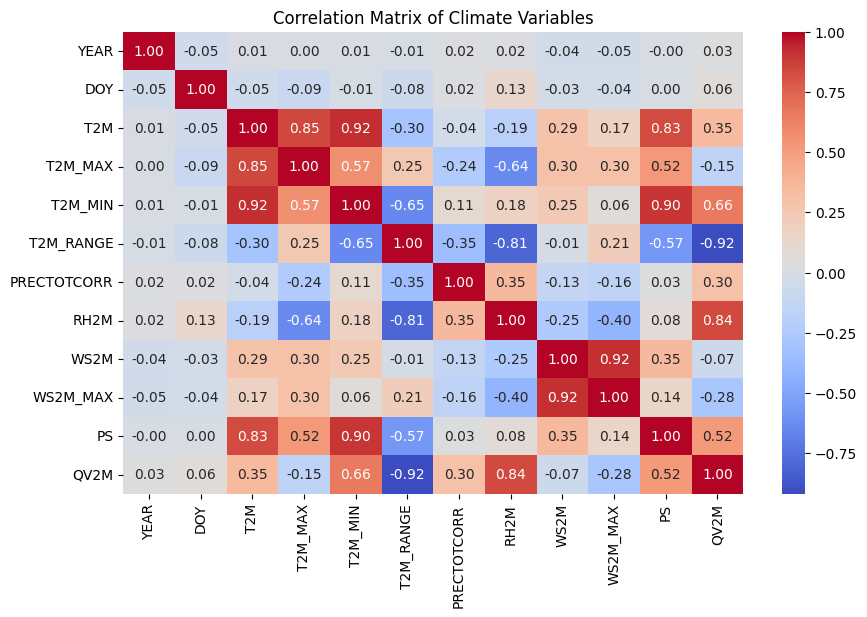

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Climate Variables")
plt.show()

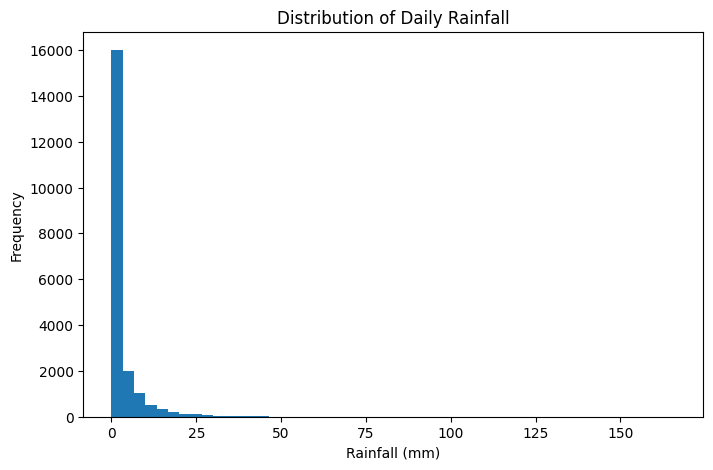

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)

plt.title("Distribution of Daily Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

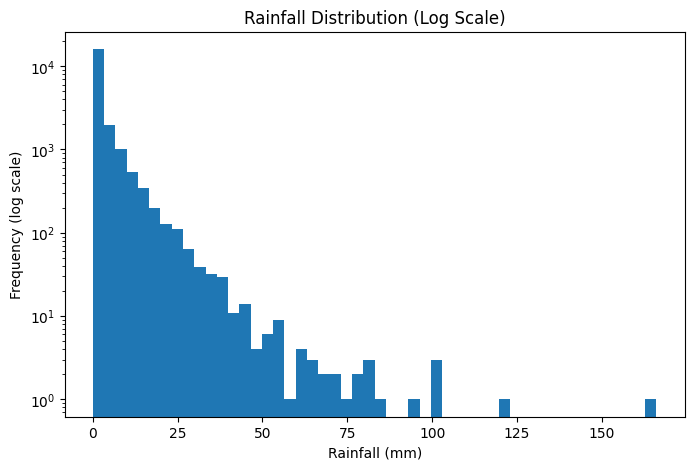

In [25]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)

plt.yscale("log")

plt.title("Rainfall Distribution (Log Scale)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency (log scale)")

plt.show()

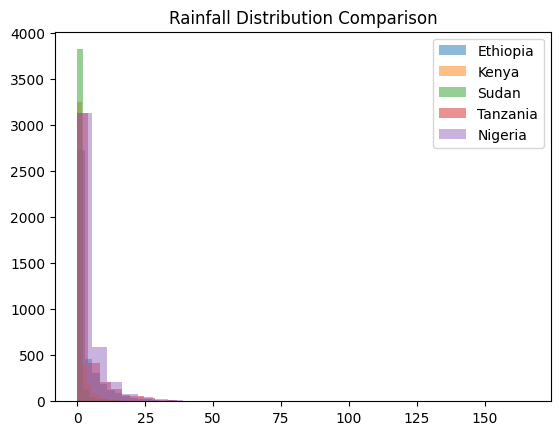

In [26]:
for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    plt.hist(subset["PRECTOTCORR"].dropna(), bins=30, alpha=0.5, label=country)

plt.legend()
plt.title("Rainfall Distribution Comparison")
plt.show()